# 06 Feature Importance

This notebook computes SHAP-based feature-importance results for the selected XGBoost model used in the thesis.

The saved XGBoost pipeline is loaded from the model-comparison outputs and applied to the fixed temporal holdout test set. SHAP values are computed at the encoded model-input level and then aggregated back to the original predictor level for the main thesis figures and table.

## 1. Import libraries

This section loads the libraries used for SHAP computation, tabular summaries, and plotting.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import platform
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from IPython.display import display

try:
    import shap
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "The SHAP package is not installed in this environment. "
        "Install it first with: pip install shap"
    ) from exc

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:.2f}".format

## 2. Define project paths and settings

This section defines the input files from earlier notebooks and the output folders for SHAP tables and figures.

In [2]:
PROJECT_DIR = Path.cwd().resolve()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR / "data"
INTERIM_DIR = DATA_DIR / "interim"
OUTPUT_DIR = PROJECT_DIR / "outputs"

MODEL_COMPARISON_TABLE_DIR = OUTPUT_DIR / "tables" / "model_comparison"
MODEL_COMPARISON_MODEL_DIR = OUTPUT_DIR / "models" / "model_comparison"

SHAP_TABLE_DIR = OUTPUT_DIR / "tables" / "feature_importance"
SHAP_FIGURE_DIR = OUTPUT_DIR / "figures" / "feature_importance"

SHAP_TABLE_DIR.mkdir(parents=True, exist_ok=True)
SHAP_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

X_TEST_PATH = INTERIM_DIR / "X_test_temporal.csv"
Y_TEST_PATH = INTERIM_DIR / "y_test_temporal.csv"
XGB_MODEL_PATH = MODEL_COMPARISON_MODEL_DIR / "xgboost_best_estimator.joblib"
SELECTED_FEATURES_PATH = MODEL_COMPARISON_TABLE_DIR / "model_comparison_selected_features.csv"

TARGET_COL = "target"
MAX_DISPLAY_FEATURES = 15

GROUPED_IMPORTANCE_PATH = SHAP_TABLE_DIR / "grouped_shap_feature_importance.csv"
GROUPED_TOP_PREDICTORS_PATH = SHAP_TABLE_DIR / "grouped_shap_top_predictors.csv"
ENCODED_IMPORTANCE_PATH = SHAP_TABLE_DIR / "encoded_shap_feature_importance.csv"
ENCODED_TOP_FEATURES_PATH = SHAP_TABLE_DIR / "encoded_shap_top_features.csv"
FEATURE_MAPPING_PATH = SHAP_TABLE_DIR / "encoded_to_original_feature_mapping.csv"
RUN_METADATA_PATH = SHAP_TABLE_DIR / "feature_importance_run_metadata.json"

GROUPED_BAR_FIGURE_PATH = SHAP_FIGURE_DIR / "grouped_shap_feature_importance.png"
GROUPED_SUMMARY_FIGURE_PATH = SHAP_FIGURE_DIR / "grouped_shap_summary_plot.png"
ENCODED_BAR_FIGURE_PATH = SHAP_FIGURE_DIR / "encoded_shap_feature_importance.png"

required_paths = [
    X_TEST_PATH,
    Y_TEST_PATH,
    XGB_MODEL_PATH,
    SELECTED_FEATURES_PATH,
]

missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "The following required files are missing:\n"
        + "\n".join(missing_paths)
        + "\n\nRun the temporal split and model comparison notebooks first."
    )

## 3. Define helper functions

This section defines small helper functions for loading features, mapping encoded columns, and aggregating SHAP values.

In [3]:
def read_target(path: Path, target_col: str = TARGET_COL) -> pd.Series:
    target_df = pd.read_csv(path)
    if target_col not in target_df.columns:
        raise ValueError(
            f"Target column '{target_col}' was not found in {path}. "
            f"Available columns: {list(target_df.columns)}"
        )
    return target_df[target_col].astype(int)


def load_selected_features(path: Path) -> list[str]:
    selected_features_df = pd.read_csv(path)

    if "feature" in selected_features_df.columns:
        feature_column = "feature"
    elif "selected_feature" in selected_features_df.columns:
        feature_column = "selected_feature"
    else:
        raise ValueError(
            "Expected a column named 'feature' or 'selected_feature' in the selected-feature table. "
            f"Available columns: {list(selected_features_df.columns)}"
        )

    return selected_features_df[feature_column].dropna().astype(str).tolist()


def clean_feature_names(feature_names: np.ndarray | list[str]) -> list[str]:
    cleaned = []
    for name in feature_names:
        cleaned_name = str(name)
        cleaned_name = cleaned_name.replace("numeric__", "")
        cleaned_name = cleaned_name.replace("categorical__", "")
        cleaned.append(cleaned_name)
    return cleaned


def infer_original_feature(encoded_feature: str, selected_features: list[str]) -> str:
    if encoded_feature in selected_features:
        return encoded_feature

    candidates = [
        feature for feature in selected_features
        if encoded_feature.startswith(f"{feature}_")
    ]

    if candidates:
        return max(candidates, key=len)

    return encoded_feature


def build_feature_mapping(encoded_features: list[str], selected_features: list[str]) -> pd.DataFrame:
    mapping_df = pd.DataFrame({"encoded_feature": encoded_features})
    mapping_df["original_predictor"] = mapping_df["encoded_feature"].apply(
        lambda name: infer_original_feature(name, selected_features)
    )
    mapping_df["is_grouped_from_encoding"] = (
        mapping_df["encoded_feature"] != mapping_df["original_predictor"]
    )
    return mapping_df


def convert_to_dense(matrix):
    if sparse.issparse(matrix):
        return matrix.toarray()
    return np.asarray(matrix)


def extract_binary_shap_values(shap_values):
    if isinstance(shap_values, list):
        if len(shap_values) == 2:
            return shap_values[1]
        return shap_values[0]

    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:
        if shap_array.shape[2] == 2:
            return shap_array[:, :, 1]
        return shap_array[:, :, 0]

    if shap_array.ndim != 2:
        raise ValueError(f"Unexpected SHAP value shape: {shap_array.shape}")

    return shap_array


def aggregate_shap_values_by_original_predictor(
    shap_values_array: np.ndarray,
    mapping_df: pd.DataFrame,
    ranked_predictors: list[str] | None = None,
) -> tuple[np.ndarray, list[str]]:
    if ranked_predictors is None:
        ranked_predictors = mapping_df["original_predictor"].drop_duplicates().tolist()

    grouped_columns = []
    for predictor in ranked_predictors:
        column_indices = mapping_df.index[
            mapping_df["original_predictor"] == predictor
        ].to_numpy()
        grouped_columns.append(shap_values_array[:, column_indices].sum(axis=1))

    return np.column_stack(grouped_columns), ranked_predictors


def display_table(df: pd.DataFrame) -> None:
    display(df.round(2))

## 4. Load the selected model and holdout test data

This section loads the fitted XGBoost pipeline and the fixed temporal holdout test set.

In [4]:
xgb_pipeline = joblib.load(XGB_MODEL_PATH)
X_test_raw = pd.read_csv(X_TEST_PATH)
y_test = read_target(Y_TEST_PATH)
selected_features = load_selected_features(SELECTED_FEATURES_PATH)

missing_features = [
    feature for feature in selected_features
    if feature not in X_test_raw.columns
]

if missing_features:
    raise ValueError(
        "Some selected features are missing from X_test_temporal.csv:\n"
        + "\n".join(missing_features)
    )

if "preprocessor" not in xgb_pipeline.named_steps or "model" not in xgb_pipeline.named_steps:
    raise ValueError(
        "The loaded XGBoost object is expected to be a sklearn Pipeline with "
        "'preprocessor' and 'model' steps."
    )

X_test = X_test_raw[selected_features].copy()
preprocessor = xgb_pipeline.named_steps["preprocessor"]
xgb_model = xgb_pipeline.named_steps["model"]

model_input_summary = pd.DataFrame({
    "item": [
        "holdout_observations",
        "selected_raw_features",
        "positive_class_count",
        "negative_class_count",
    ],
    "value": [
        X_test.shape[0],
        len(selected_features),
        int((y_test == 1).sum()),
        int((y_test == 0).sum()),
    ],
})

display_table(model_input_summary)

,item,value
0,holdout_observations,1141
1,selected_raw_features,19
2,positive_class_count,781
3,negative_class_count,360


## 5. Transform the holdout test set

This section applies the fitted preprocessing pipeline and retrieves the encoded model-input feature names.

In [5]:
X_test_processed = preprocessor.transform(X_test)

try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError as exc:
    raise AttributeError(
        "Could not retrieve feature names from the fitted preprocessor. "
        "Check the scikit-learn version and ColumnTransformer object."
    ) from exc

feature_names_clean = clean_feature_names(feature_names)
X_test_processed_array = convert_to_dense(X_test_processed)

if X_test_processed_array.shape[1] != len(feature_names_clean):
    raise ValueError(
        "The number of processed columns does not match the number of retrieved feature names."
    )

X_test_processed_df = pd.DataFrame(
    X_test_processed_array,
    columns=feature_names_clean,
    index=X_test.index,
)

feature_mapping_df = build_feature_mapping(feature_names_clean, selected_features)

processed_feature_summary = pd.DataFrame({
    "item": [
        "encoded_model_input_features",
        "original_predictors_after_grouping",
    ],
    "value": [
        X_test_processed_df.shape[1],
        feature_mapping_df["original_predictor"].nunique(),
    ],
})

display_table(processed_feature_summary)

,item,value
0,encoded_model_input_features,419
1,original_predictors_after_grouping,19


## 6. Compute SHAP values

This section computes SHAP values for the fixed temporal holdout test set.

In [6]:
explainer = shap.TreeExplainer(xgb_model)
raw_shap_values = explainer.shap_values(X_test_processed_array)
shap_values = extract_binary_shap_values(raw_shap_values)

if shap_values.shape != X_test_processed_array.shape:
    raise ValueError(
        "The SHAP-value matrix shape does not match the processed test matrix shape. "
        f"SHAP shape: {shap_values.shape}; processed X_test shape: {X_test_processed_array.shape}"
    )

shap_value_summary = pd.DataFrame({
    "item": [
        "holdout_observations",
        "encoded_features",
    ],
    "value": [
        shap_values.shape[0],
        shap_values.shape[1],
    ],
})

display_table(shap_value_summary)

,item,value
0,holdout_observations,1141
1,encoded_features,419


## 7. Create SHAP importance tables

This section creates encoded feature-level and grouped original-predictor-level SHAP importance tables.

In [7]:
encoded_importance_df = pd.DataFrame({
    "feature": feature_names_clean,
    "original_predictor": feature_mapping_df["original_predictor"].to_numpy(),
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    "mean_shap": shap_values.mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

encoded_importance_df["rank"] = np.arange(1, len(encoded_importance_df) + 1)
encoded_importance_df = encoded_importance_df[[
    "rank", "feature", "original_predictor", "mean_abs_shap", "mean_shap"
]]
encoded_top_features_df = encoded_importance_df.head(MAX_DISPLAY_FEATURES).copy()

all_grouped_shap_values, all_grouped_predictors = aggregate_shap_values_by_original_predictor(
    shap_values,
    feature_mapping_df,
)

grouped_importance_df = pd.DataFrame({
    "predictor": all_grouped_predictors,
    "mean_abs_shap": np.abs(all_grouped_shap_values).mean(axis=0),
    "mean_shap": all_grouped_shap_values.mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

grouped_importance_df["rank"] = np.arange(1, len(grouped_importance_df) + 1)
grouped_importance_df = grouped_importance_df[[
    "rank", "predictor", "mean_abs_shap", "mean_shap"
]]
grouped_top_predictors_df = grouped_importance_df.head(MAX_DISPLAY_FEATURES).copy()

ranked_grouped_predictors = grouped_importance_df["predictor"].tolist()
grouped_shap_values, grouped_predictors = aggregate_shap_values_by_original_predictor(
    shap_values,
    feature_mapping_df,
    ranked_predictors=ranked_grouped_predictors,
)

grouped_shap_df = pd.DataFrame(
    grouped_shap_values,
    columns=grouped_predictors,
    index=X_test.index,
)

display_table(grouped_top_predictors_df)
display_table(encoded_top_features_df)

,rank,predictor,mean_abs_shap,mean_shap
0,1,market,0.21,-0.19
1,2,funding_total_usd,0.13,-0.06
2,3,has_round_c,0.06,0.06
3,4,founded_year,0.05,-0.02
4,5,debt_financing,0.04,0.01
5,6,country_code,0.04,0.01
6,7,funding_duration_days,0.04,0.03
7,8,venture,0.03,-0.02
8,9,private_equity,0.03,0.03
9,10,angel,0.03,-0.03


,rank,feature,original_predictor,mean_abs_shap,mean_shap
0,1,market_ Clean Technology,market,0.13,-0.13
1,2,funding_total_usd,funding_total_usd,0.13,-0.06
2,3,has_round_c,has_round_c,0.06,0.06
3,4,founded_year,founded_year,0.05,-0.02
4,5,country_code_CAN,country_code,0.05,0.05
5,6,market_ Biotechnology,market,0.05,-0.05
6,7,debt_financing,debt_financing,0.04,0.01
7,8,funding_duration_days,funding_duration_days,0.04,0.03
8,9,market_ Enterprise Software,market,0.04,0.04
9,10,venture,venture,0.03,-0.02


## 8. Create grouped SHAP feature-importance figure

This section creates the grouped SHAP bar plot used to rank original predictors by mean absolute SHAP value.

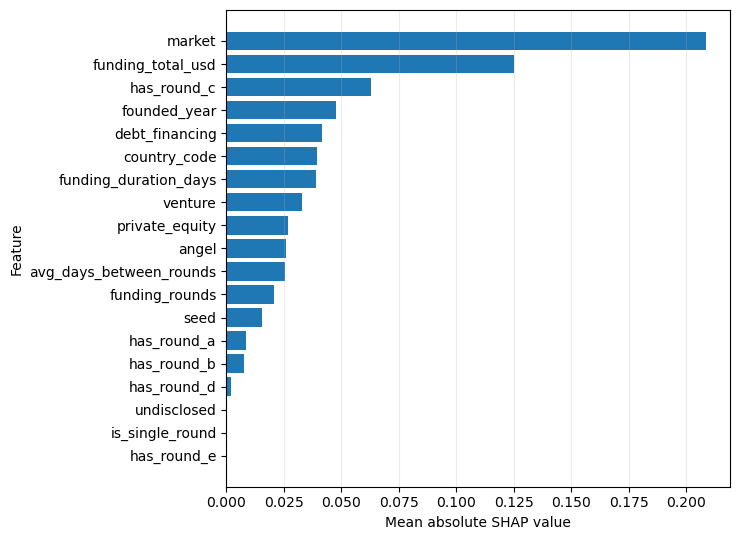

In [8]:
top_grouped_plot_df = grouped_importance_df.sort_values("mean_abs_shap", ascending=True)

fig_grouped_bar, ax = plt.subplots(figsize=(7.5, 5.5))
ax.barh(top_grouped_plot_df["predictor"], top_grouped_plot_df["mean_abs_shap"])
ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.25)
fig_grouped_bar.tight_layout()
plt.show()

## 9. Create grouped SHAP summary figure

This section creates the grouped SHAP summary plot showing the direction and spread of original-predictor contributions.

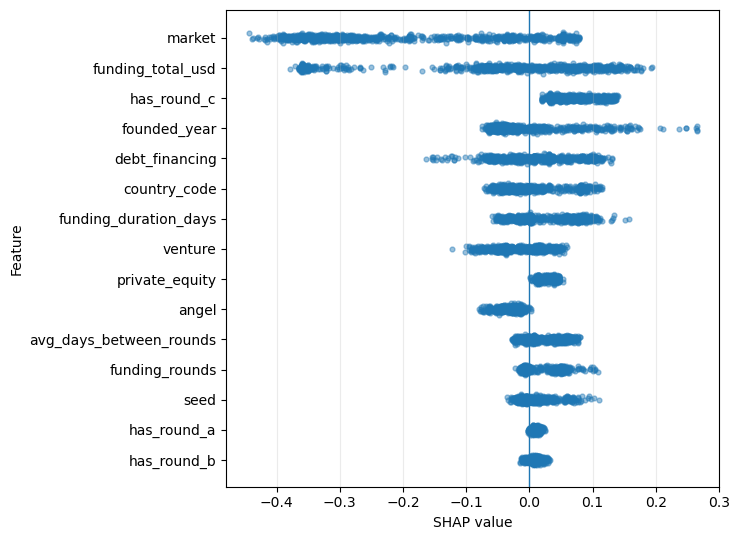

In [12]:
def create_grouped_summary_plot(
    grouped_shap_values: np.ndarray,
    grouped_feature_names: list[str],
    max_display: int = 15,
):
    mean_abs_values = np.abs(grouped_shap_values).mean(axis=0)
    order = np.argsort(mean_abs_values)[::-1][:max_display]

    selected_names = [grouped_feature_names[i] for i in order]
    selected_values = grouped_shap_values[:, order]

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    rng = np.random.default_rng(2026)

    for y_pos, predictor_idx in enumerate(range(len(selected_names))):
        values = selected_values[:, predictor_idx]
        jitter = rng.normal(loc=0, scale=0.055, size=len(values))
        y_values = np.full(len(values), y_pos) + jitter

        ax.scatter(
            values,
            y_values,
            s=12,
            alpha=0.45,
            color="tab:blue"
        )

    ax.axvline(0, linewidth=1)
    ax.set_yticks(range(len(selected_names)))
    ax.set_yticklabels(selected_names)
    ax.invert_yaxis()

    ax.set_xlabel("SHAP value")
    ax.set_ylabel("Feature")

    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", visible=False)

    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    fig.tight_layout()
    return fig


fig_grouped_summary = create_grouped_summary_plot(
    grouped_shap_values=grouped_shap_values,
    grouped_feature_names=grouped_predictors,
    max_display=MAX_DISPLAY_FEATURES,
)

plt.show()

## 10. Create encoded SHAP feature-importance figure

This section creates the encoded feature-level SHAP importance figure used for the appendix-level result.

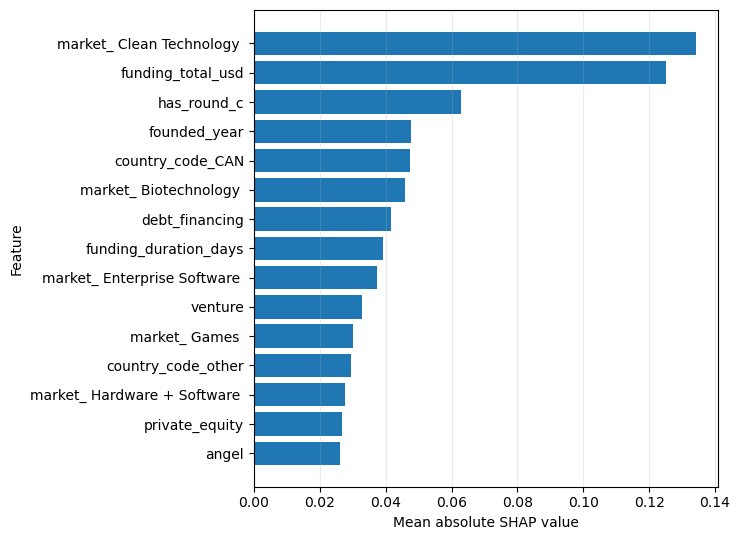

In [13]:
top_encoded_plot_df = encoded_top_features_df.sort_values("mean_abs_shap", ascending=True)

fig_encoded_bar, ax = plt.subplots(figsize=(7.5, 5.5))
ax.barh(top_encoded_plot_df["feature"], top_encoded_plot_df["mean_abs_shap"])
ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.25)
fig_encoded_bar.tight_layout()
plt.show()

## 11. Save outputs

This section saves the SHAP tables, figures, feature mapping, and run metadata generated above.

In [14]:
grouped_importance_df.to_csv(GROUPED_IMPORTANCE_PATH, index=False)
grouped_top_predictors_df.to_csv(GROUPED_TOP_PREDICTORS_PATH, index=False)
encoded_importance_df.to_csv(ENCODED_IMPORTANCE_PATH, index=False)
encoded_top_features_df.to_csv(ENCODED_TOP_FEATURES_PATH, index=False)
feature_mapping_df.to_csv(FEATURE_MAPPING_PATH, index=False)

fig_grouped_bar.savefig(
    GROUPED_BAR_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig_grouped_summary.savefig(
    GROUPED_SUMMARY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig_encoded_bar.savefig(
    ENCODED_BAR_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

run_metadata = {
    "analysis": "SHAP feature importance for the selected XGBoost model",
    "model_path": str(XGB_MODEL_PATH),
    "x_test_path": str(X_TEST_PATH),
    "y_test_path": str(Y_TEST_PATH),
    "selected_features_path": str(SELECTED_FEATURES_PATH),
    "n_holdout_observations": int(X_test.shape[0]),
    "n_selected_raw_features": int(len(selected_features)),
    "n_encoded_features": int(X_test_processed_df.shape[1]),
    "n_grouped_predictors": int(len(grouped_predictors)),
    "positive_class": {"label": "acquired", "code": 1},
    "negative_class": {"label": "closed", "code": 0},
    "importance_measure_encoded": "mean absolute SHAP value at encoded feature level",
    "importance_measure_grouped": "mean absolute value of SHAP contributions aggregated by original predictor",
    "output_paths": {
        "grouped_importance": str(GROUPED_IMPORTANCE_PATH),
        "grouped_top_predictors": str(GROUPED_TOP_PREDICTORS_PATH),
        "encoded_importance": str(ENCODED_IMPORTANCE_PATH),
        "encoded_top_features": str(ENCODED_TOP_FEATURES_PATH),
        "feature_mapping": str(FEATURE_MAPPING_PATH),
        "grouped_bar_figure": str(GROUPED_BAR_FIGURE_PATH),
        "grouped_summary_figure": str(GROUPED_SUMMARY_FIGURE_PATH),
        "encoded_bar_figure": str(ENCODED_BAR_FIGURE_PATH),
    },
}

with open(RUN_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)